In [51]:
%cd /content
!git clone https://github.com/23064088/DataMiningGroup18.git
%cd DataMiningGroup18
!git checkout random_forest
!git status


/content
fatal: destination path 'DataMiningGroup18' already exists and is not an empty directory.
/content/DataMiningGroup18
M	random_forest_results.txt
Already on 'random_forest'
Your branch is up to date with 'origin/random_forest'.
On branch random_forest
Your branch is up to date with 'origin/random_forest'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   random_forest_results.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Financial Data.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [52]:
import pandas as pd
import numpy as np

df = pd.read_csv("Financial Data.csv")
display(df.head())

# Drop non-predictive / raw text columns
df = df.drop(columns=["id_num", "customer_statement", "risk_flag"])

TARGET = "loan_default"

print(df[TARGET].value_counts())


,id_num,age,monthly_income,credit_score,loan_amount,interest_rate,debt_to_income_ratio,late_payment_count_12m,financial_confidence,bank_type,risk_keywords_present,customer_statement,loan_default,risk_flag,Sentiment_Score
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,59,3360,578,43158,19.639879,12.844643,0,Medium,Traditional,0,I am writing to report financial difficulties ...,1,2,0.500000
1,23b8c1e9-3924-46de-beb1-3b9046685257,42,3269,648,7433,8.636499,2.273784,0,Low,Traditional,0,I want to invest my savings in the very moment...,0,0,0.500000
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,62,4547,718,7747,12.327237,1.703761,0,Medium,Digital,0,I want to invest my savings in the next year. ...,1,0,0.500000
3,972a8469-1641-4f82-8b9d-2434e465e150,41,7893,667,15627,23.844035,1.979856,1,Medium,Traditional,0,I want to invest my savings in the next year. ...,0,0,0.500000
4,17fc695a-07a0-4a6e-8822-e8f36c031199,64,3275,573,49974,8.467293,15.259237,1,Low,Traditional,0,I am writing to report financial difficulties ...,1,2,0.313378


loan_default
1    1083
0     917
Name: count, dtype: int64


In [53]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['age', 'monthly_income', 'credit_score', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'late_payment_count_12m', 'risk_keywords_present', 'Sentiment_Score']
Categorical columns: ['financial_confidence', 'bank_type']


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model.fit(X_train, y_train)
print("Trained Random Forest on Financial Data.csv")

Trained Random Forest on Financial Data.csv


In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

Accuracy: 0.7325
F1 Score: 0.7265507701940339
Precision: 0.7338895281933256
Recall: 0.7252020850645917

Confusion Matrix:
 [[117  66]
 [ 41 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.64      0.69       183
           1       0.73      0.81      0.77       217

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400

ROC-AUC: 0.8038578731333889


In [56]:
from sklearn.metrics import accuracy_score, f1_score

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average="macro")
test_f1  = f1_score(y_test, y_test_pred, average="macro")

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Train Macro F1: {train_f1:.4f}")
print(f"Test Macro F1 : {test_f1:.4f}")

# Simple interpretation rule
acc_gap = train_acc - test_acc
f1_gap  = train_f1 - test_f1

if acc_gap > 0.10 or f1_gap > 0.10:
    fit_label = "Overfitting"
elif train_acc < 0.65 and test_acc < 0.65:
    fit_label = "Underfitting"
else:
    fit_label = "Good Fit"

print("\nFit Diagnosis:", fit_label)
print(f"Accuracy gap = {acc_gap:.4f}, F1 gap = {f1_gap:.4f}")


Train Accuracy: 0.8056
Test Accuracy : 0.7325
Train Macro F1: 0.8038
Test Macro F1 : 0.7266

Fit Diagnosis: Good Fit
Accuracy gap = 0.0731, F1 gap = 0.0772


In [57]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = num_cols + list(cat_features)
importances = model.named_steps["rf"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi.head(15))


,feature,importance
5,debt_to_income_ratio,0.313346
1,monthly_income,0.180312
2,credit_score,0.170336
3,loan_amount,0.130022
4,interest_rate,0.061785
0,age,0.050787
6,late_payment_count_12m,0.029942
8,Sentiment_Score,0.018278
7,risk_keywords_present,0.010593
11,financial_confidence_Medium,0.008491


In [58]:
import pandas as pd

# If you used Pipeline:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances = model.named_steps["rf"].feature_importances_

clean_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

feat_imp = pd.Series(importances, index=clean_names).sort_values(ascending=False)

print("Top 10 features by importance:")
print(feat_imp.head(10).to_string())


Top 10 features by importance:
debt_to_income_ratio           0.313346
monthly_income                 0.180312
credit_score                   0.170336
loan_amount                    0.130022
interest_rate                  0.061785
age                            0.050787
late_payment_count_12m         0.029942
Sentiment_Score                0.018278
risk_keywords_present          0.010593
financial_confidence_Medium    0.008491


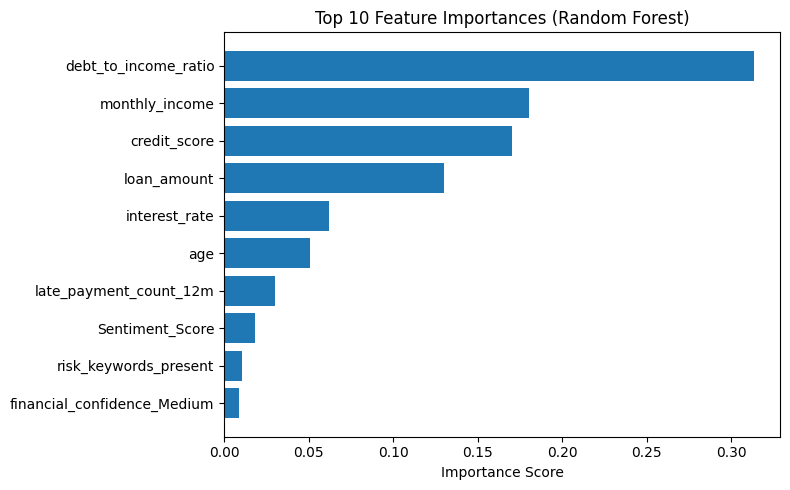

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract trained Random Forest
rf_model = model.named_steps["rf"]

# Get feature names
ohe = model.named_steps["preprocess"] \
           .named_transformers_["cat"] \
           .named_steps["onehot"]

cat_features = ohe.get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_features)

# Get importance values
importances = rf_model.feature_importances_

# Create DataFrame
fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select top 10
top_fi = fi.head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top_fi["Feature"], top_fi["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [60]:
from sklearn.metrics import f1_score

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

with open("random_forest_results.txt", "w") as f:
    f.write("Random Forest Results\n")
    f.write(f"Target: {TARGET}\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score (macro): {f1:.4f}\n\n")
    f.write(f"Fit Diagnosis:\n")
    f.write(f"Train Accuracy: {train_acc:.4f}\n")
    f.write(f"Test Accuracy : {test_acc:.4f}\n")
    f.write(f"Train Macro F1: {train_f1:.4f}\n")
    f.write(f"Test Macro F1 : {test_f1:.4f}\n\n")
    f.write(f"Diagnosis: {fit_label}\n")
    f.write(f"Accuracy gap = {acc_gap:.4f}\n")
    f.write(f"F1 gap = {f1_gap:.4f}\n\n")
    f.write("Top 10 Features:\n")
    for _, row in fi.head(10).iterrows():
        f.write(f"- {row['Feature']}: {row['Importance']:.4f}\n")

print("Saved random_forest_results.txt")

Saved random_forest_results.txt
